# Replicating Italian day-ahead prices with OpenEUPHEMIA

[EUPHEMIA](https://www.nemo-committee.eu/sdac) clears the European day-ahead
market: it maximizes economic welfare over every submitted order subject to
the network constraints, and the resulting zonal prices settle billions of
euros of energy a year. The algorithm is publicly described, but its
implementation is closed.

This notebook rebuilds one country of it from published data alone. We
assemble the seven Italian bidding zones step by step — topology, bid
curves, transfer capacities, boundary conditions — clear the market, and
compare the prices we get against the ones GME actually published.

The result: **every zone-hour of April 2025 reproduced exactly**, without
ever looking at an observed flow.

In [1]:
import pathlib
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/rebase-energy/OpenEUPHEMIA.git
    %pip install -q "./OpenEUPHEMIA[notebook]"
    ROOT = pathlib.Path("OpenEUPHEMIA")
else:
    ROOT = next(
        parent
        for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
        if (parent / "data" / "italy").is_dir()
    )

sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "italy" / "2025-04"
print("repository root:", ROOT)

repository root: /Users/sebaheg/Documents/Github/OpenEUPHEMIA


## 1. The inputs

Three tidy tables, all derived from GME's public publications and committed
to the repository (see [`data/italy`](../data/italy)). Data collection is
deliberately not part of the library — OpenEUPHEMIA is about building,
closing, and clearing markets.

| Table | What it is |
|---|---|
| `bid-curves` | the aggregated order book: one row per zone, hour, side, and price step |
| `transfer-capacities` | the published transfer limit of every edge, internal and cross-border |
| `published-prices` | the prices GME published, for the Italian zones **and** their neighbours |

The Italian prices are our validation target and are never given to the
solver. The neighbours' prices are — that is the boundary condition.

In [2]:
import pandas as pd

bid_curves = pd.read_csv(DATA / "bid-curves.csv.gz")
transfer_capacities = pd.read_csv(DATA / "transfer-capacities.csv.gz")
published_prices = pd.read_csv(DATA / "published-prices.csv.gz")

DAY = "2025-04-01"
print(f"{len(bid_curves):,} curve rows over {bid_curves.delivery_day.nunique()} days")
bid_curves[bid_curves.delivery_day == DAY].head()

535,765 curve rows over 30 days


,delivery_day,period,zone,side,price_eur_per_mwh,quantity_mwh
0,2025-04-01,1,CALA,demand,-500.0,0.8
1,2025-04-01,1,CALA,demand,-499.0,0.3
2,2025-04-01,1,CALA,demand,34.5,0.1
3,2025-04-01,1,CALA,demand,71.1,0.5
4,2025-04-01,1,CALA,demand,78.0,28.7


## 2. Topology

A `System` holds the zones and the links between them — topology only, so it
can be reused across delivery days. Italy has seven bidding zones connected
by six internal links; everything else that appears in the capacity table is
a border with a neighbouring country.

In [3]:
from openeuphemia import Market, System
from openeuphemia.italy import ITALY_PRICE_AREAS
from openeuphemia.italy.replication import internal_transfer_capacities

capacities = internal_transfer_capacities(
    transfer_capacities,
    delivery_day=DAY,
    zones=ITALY_PRICE_AREAS,
)
links = sorted({(row.from_zone, row.to_zone) for row in capacities.itertuples()})

system = System(zones=list(ITALY_PRICE_AREAS), interconnectors=links)
market = Market(name="italy", delivery_day=DAY, system=system, periods=list(range(1, 25)))
system

System(zones=7, interconnectors=6)

## 3. Bid curves

Every bid and offer submitted for a zone and hour is aggregated into one
supply and one demand curve. A `BidCurve` is a cumulative price/volume
staircase: supply rises with price, demand falls.

`bid_curves_from_table` turns the tidy rows into `{"supply": ..., "demand": ...}`
mappings, which go straight into `add_bid_curve`.

In [4]:
from openeuphemia import bid_curves_from_table
from openeuphemia.italy.replication import rows_for_day

curves = bid_curves_from_table(rows_for_day(bid_curves, DAY))

for (period, zone), sides in sorted(curves.items()):
    market.add_bid_curve(zone=zone, period=period, **sides)

print(f"{len(curves)} zone-hours -> {len(market.orders):,} orders")

168 zone-hours -> 18,060 orders


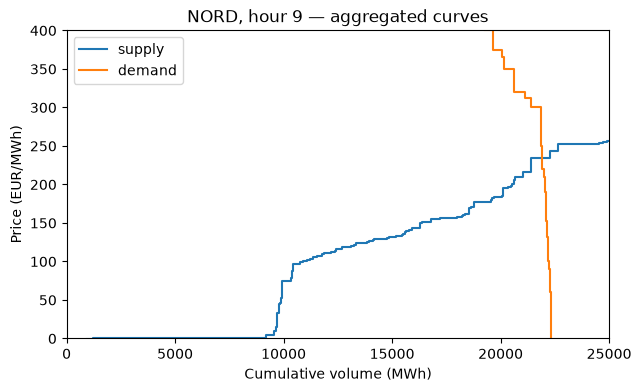

In [5]:
import matplotlib.pyplot as plt

supply = curves[(9, "NORD")]["supply"]
demand = curves[(9, "NORD")]["demand"]

fig, ax = plt.subplots(figsize=(7, 4))
supply.plot(ax=ax, label="supply")
demand.plot(ax=ax, label="demand")
ax.set_xlim(0, 25_000)
ax.set_ylim(0, 400)
ax.set_title("NORD, hour 9 — aggregated curves")
ax.legend()
plt.show()

The curves cross where the market clears. Note the vertical segments at the
extremes: price-taking volume that will be accepted at any price, including
the accepted block orders fixed at their published awarded quantity.

## 4. Internal transfer capacities

`set_ntc` sets how much power each link may carry, per hour and per
direction. These limits are what makes prices diverge between zones: when a
link saturates, the zones on either side stop sharing a price.

In [6]:
for row in capacities.itertuples():
    market.set_ntc(
        row.from_zone,
        row.to_zone,
        period=row.period,
        forward_capacity_mwh=row.forward_capacity_mwh,
        reverse_capacity_mwh=row.reverse_capacity_mwh,
    )

capacities.head()

,period,from_zone,to_zone,forward_capacity_mwh,reverse_capacity_mwh
0,1,CALA,SICI,1567.0,1048.0
1,1,CALA,SUD,2350.0,1733.0
2,1,CNOR,CSUD,4273.0,3106.0
3,1,CNOR,NORD,2868.0,3976.0
4,1,CSUD,SARD,720.0,870.0


## 5. Boundary conditions

Italy is not an island: it trades with France, Switzerland, Austria,
Slovenia, Greece, Montenegro and Corsica. Rather than model all of Europe,
we close the model at the border.

`add_fixed_price_boundary` makes each border a **price taker** at the
neighbouring zone's published price, free to trade anything within the
published border capacity — a Dirichlet boundary condition. The alternative,
`add_fixed_flow_boundary`, would pin the exchange at an observed volume; we
deliberately do not use it, because observed flows are an *outcome* of the
clearing we are trying to reproduce.

In [7]:
from openeuphemia.italy.replication import (
    external_boundary_prices,
    external_capacity_bounds,
    price_mapping,
)

prices_by_zone = price_mapping(published_prices, delivery_day=DAY)
neighbour_prices = {
    key: value for key, value in prices_by_zone.items() if key[1] not in ITALY_PRICE_AREAS
}

external_bounds = external_capacity_bounds(
    transfer_capacities,
    delivery_day=DAY,
    zones=ITALY_PRICE_AREAS,
)
border_prices, diagnostics = external_boundary_prices(external_bounds, neighbour_prices)

for row in border_prices.itertuples():
    market.add_fixed_price_boundary(
        id=row.id,
        period=row.period,
        zone=row.zone,
        external_zone=row.external_zone,
        price_eur_per_mwh=row.price_eur_per_mwh,
        import_capacity_mwh=row.import_capacity_mwh,
        export_capacity_mwh=row.export_capacity_mwh,
    )

print(f"{len(border_prices)} price-taking borders, "
      f"{(diagnostics.treatment == 'unpriced-dropped').sum()} dropped for lack of a price")
diagnostics.head()

288 price-taking borders, 0 dropped for lack of a price


,period,id,zone,external_zone,external_price_eur_per_mwh,import_capacity_mwh,export_capacity_mwh,treatment
0,1,AUST_NORD,NORD,AUST,105.3,10000.0,10000.0,open
1,1,CNOR_CORS,CNOR,CORS,105.3,150.0,150.0,open
2,1,COAC_SARD,SARD,COAC,105.3,20.0,125.0,open
3,1,CORS_SARD,SARD,CORS,105.3,150.0,150.0,open
4,1,COUP_NORD,NORD,COUP,105.3,10000.0,10000.0,open


## 6. Clear

The market is complete. Clearing maximizes welfare — the area between the
accepted demand and supply steps — subject to the zonal balance, the link
limits, and the border capacities. Zonal prices are the **dual values** of
the balance constraints, which is exactly how EUPHEMIA defines them.

In [8]:
result = market.clear(method="per-period-lp")
print(result.status, f"welfare {result.objective_value:,.0f} EUR")
result.prices.head(7)

optimal welfare 2,279,321,994 EUR


,period,zone,price_eur_per_mwh
0,1,CALA,105.3
1,1,CNOR,105.3
2,1,CSUD,105.3
3,1,NORD,105.3
4,1,SARD,105.3
5,1,SICI,105.3
6,1,SUD,105.3


## 7. Did we get it right?

Compare against the published Italian prices, hour by hour and zone by zone.

In [9]:
from openeuphemia.italy import compare_prices, summarize_price_comparison

italian_prices = {
    key: value for key, value in prices_by_zone.items() if key[1] in ITALY_PRICE_AREAS
}
comparison = compare_prices(result.prices, italian_prices, delivery_day=DAY)
summarize_price_comparison(comparison)

{'price_rows': 168,
 'matched_rows': 168,
 'exact_rows': 168,
 'price_mae_eur_per_mwh': 0.0,
 'price_max_abs_error_eur_per_mwh': 0.0}

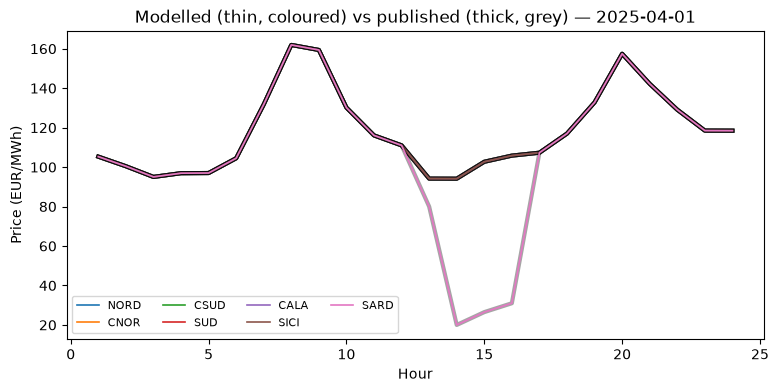

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for zone in ITALY_PRICE_AREAS:
    rows = comparison[comparison.zone == zone].sort_values("period")
    ax.plot(rows.period, rows.published_price_eur_per_mwh, lw=3, alpha=0.35, color="black")
    ax.plot(rows.period, rows.modelled_price_eur_per_mwh, lw=1.2, label=zone)
ax.set_xlabel("Hour")
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title(f"Modelled (thin, coloured) vs published (thick, grey) — {DAY}")
ax.legend(ncol=4, fontsize=8)
plt.show()

The coloured lines sit exactly on top of the grey ones — 168 of 168
zone-hours reproduced to the cent.

## 8. The whole month

One day could be luck. `replicate_italy_day` runs the same build-and-clear
we just did by hand, so we can sweep all 30 days of April 2025.

In [11]:
from openeuphemia.italy import delivery_days, replicate_italy_day

comparisons = []
for day in delivery_days(bid_curves):
    day_result = replicate_italy_day(
        delivery_day=day,
        bid_curves=bid_curves,
        transfer_capacities=transfer_capacities,
        published_prices=published_prices,
    )
    comparisons.append(day_result.price_comparison)

month = pd.concat(comparisons, ignore_index=True)
summarize_price_comparison(month)

{'price_rows': 5040,
 'matched_rows': 5040,
 'exact_rows': 5040,
 'price_mae_eur_per_mwh': 0.0,
 'price_max_abs_error_eur_per_mwh': 0.0}

In [12]:
worst = month.sort_values("absolute_error_eur_per_mwh", ascending=False).head()
print(f"largest absolute error anywhere in the month: "
      f"{month.absolute_error_eur_per_mwh.max():.6f} EUR/MWh")
worst

largest absolute error anywhere in the month: 0.000000 EUR/MWh


,delivery_day,period,zone,modelled_price_eur_per_mwh,published_price_eur_per_mwh,error_eur_per_mwh,absolute_error_eur_per_mwh
0,2025-04-01,1,CALA,105.30000,105.30000,0.0,0.0
3357,2025-04-20,24,SARD,111.24132,111.24132,0.0,0.0
3364,2025-04-21,1,SARD,100.00000,100.00000,0.0,0.0
3363,2025-04-21,1,NORD,100.00000,100.00000,0.0,0.0
3362,2025-04-21,1,CSUD,100.00000,100.00000,0.0,0.0


## What this shows

**5,040 of 5,040 zone-hours exact.** Given the published order book and the
published transfer capacities, welfare maximization has a unique price
solution, and it is the one GME published. Two things are worth drawing out:

- **The border prices are a sufficient statistic for the rest of Europe.**
  We never modelled France or Greece, only priced the borders with them, and
  that was enough to recover every Italian price.
- **No observed flows were used.** Scheduled exchanges and internal flows are
  outcomes of the clearing; feeding them back in would make the exercise
  circular. Reproducing the *flows* blind is a harder problem, because equal
  prices leave the flow split genuinely indeterminate — that is the next
  milestone.

The same three tables — curves, capacities, border prices — are all any
other bidding zone needs. Adding a region to OpenEUPHEMIA means preparing
them and proving the clearing reproduces what was published.